# Lab 2: From Raw Data to ML-Ready Data
## Data Cleaning & Exploratory Data Analysis — Telco Customer Churn

**Name:** Muhammad Hussain

**Roll Number:** 023-24-0003

**GitHub Repository:** (https://github.com/hussainwaseer/machine-learning-lab-2)

**Duration:** 3 Hours (independent, hands-on)


---

## Setup

Import the libraries you'll need and load the dataset. Use the Telco Customer Churn CSV provided for this lab.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("Telco-Customer-Churn.csv")   # update path/filename if different


---

## Part 1 — The Business Problem

A telecommunications company is losing customers to competitors — this is called **customer churn**. The company wants to understand which customers are likely to leave, so it can intervene early. Before any model can be built, the raw data must be understood, audited for quality issues, and explored.

**Tasks**
1. In 2–3 sentences, state the business problem in your own words, and propose what the target variable likely is.
2. List 5 columns you expect to be useful predictors of churn, and 2 columns you expect to be useless as predictors — justify each choice in one line.
3. Write down 2 questions you personally want this data to answer about customers who churn.

**Answer 1:**`
_(The telecommunications company wants to identify customers who are likely to leave. The goal is to analyze customer information and services to understand and predict customer churn.Target Variable : Churn)_

**Answer 2:**
**Answer 2:**
| Column             | Why useful?                                                                                                    |
| ------------------ | -------------------------------------------------------------------------------------------------------------- |
| **PaymentMethod**  | Different payment methods may be associated with different customer churn patterns.                            |
| **MonthlyCharges** | Higher monthly charges may increase the likelihood of customers leaving.                                       |
| **OnlineSecurity** | Customers without security services may be more likely to switch providers.                                    |
| **TechSupport**    | Lack of technical support may contribute to customer dissatisfaction and churn.                                |
| **Contract**       | Customers on month-to-month contracts are generally more likely to leave than customers with longer contracts. |

| Column         | Why useless?                                                                                        |
| -------------- | --------------------------------------------------------------------------------------------------- |
| **customerID** | It is only a unique identifier and does not contain meaningful information about customer behavior. |
| **gender**     | Gender does not directly describe the customer's usage, billing, or relationship with the company.  |

**Answer 3:**
Here are two other straightforward questions:

1. **Are customers without technical support more likely to churn?**
2. **Does the payment method affect the likelihood of customer churn?**

---

## Part 2 — Exploring the Dataset Structure

Before cleaning or analyzing anything, get an accurate picture of the dataset's shape and contents. Running a command is not the same as understanding its output — you must interpret what you see.

*Concepts/functions you may find useful:* `df.shape`, `df.columns`, `df.dtypes`, `df.info()`, `df.head()`, `df.sample(n)`, `df[col].unique()`, `df[col].nunique()`, `df.describe(include='all')`

**Tasks**
4. How many customers and how many features are in this dataset? List the numerical features and the categorical features separately.
5. Identify any column(s) that are simply identifiers rather than predictive features, and any column(s) whose data type looks wrong for what it represents.
6. Pick 3 categorical columns and report their unique values — do any contain unexpected or inconsistent categories?

In [3]:
# Task 4 — dataset shape, column names, data types
print(df.shape)
print(df.columns)
print(df.dtypes)

(7043, 21)
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [4]:
# Task 5 — identify identifier columns / wrong data types
print("customerID unique values:", df["customerID"].nunique(), "of", len(df))
print("customerID dtype:", df["customerID"].dtype)
print("TotalCharges dtype before cleaning:", df["TotalCharges"].dtype)

tc = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("\nRows where TotalCharges is blank/non-numeric:")
display(df.loc[tc.isna(), ["customerID", "tenure", "TotalCharges"]])


customerID unique values: 7043 of 7043
customerID dtype: str
TotalCharges dtype before cleaning: str

Rows where TotalCharges is blank/non-numeric:


,customerID,tenure,TotalCharges
488,4472-LVYGI,0,
753,3115-CZMZD,0,
936,5709-LVOEQ,0,
1082,4367-NUYAO,0,
1340,1371-DWPAZ,0,
3331,7644-OMVMY,0,
3826,3213-VVOLG,0,
4380,2520-SGTTA,0,
5218,2923-ARZLG,0,
6670,4075-WKNIU,0,


In [5]:
# Task 6 — unique values in 3 categorical columns
for col in ["Contract", "InternetService", "PaymentMethod"]:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False))


Contract:
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

InternetService:
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

PaymentMethod:
PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64


**Observations (Part 2):**
_(summarize what you found — numerical features, categorical features, suspicious columns, etc.)_

---

## Part 3 — Investigating Data Quality

A dataset can look clean at a glance and still hide serious problems. You must actively search for missing values, duplicates, and suspicious values rather than assume there are none.

*Concepts/functions you may find useful:* `df.isnull().sum()`, `df.isnull().mean()*100`, `df.duplicated().sum()`, `df['id_col'].duplicated().sum()`, `df[col].value_counts()`

**Tasks**
7. Report missing values as both a count and a percentage per column. Which missing-value problems do you think require action, and which don't? Justify your reasoning.
8. Check for duplicate rows and duplicate customer IDs separately — are they the same issue or different issues?
9. Find at least one column with a suspicious, invalid, or inconsistently formatted value, and describe how you found it.

In [6]:
# Task 7 — missing values: count and percentage per column
null_count = df.isna().sum()
null_percent = (null_count / df.shape[0]) * 100

print(f"Number of empty cells by column:\n{null_count}")
print(f"Percentage of empty cells:\n{null_percent}")

Number of empty cells by column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
Percentage of empty cells:
customerID          0.0
gender              0.0
SeniorCitizen       0.0
Partner             0.0
Dependents          0.0
tenure              0.0
PhoneService        0.0
MultipleLines       0.0
InternetService     0.0
OnlineSecurity      0.0
OnlineBackup        0.0
DeviceProtection    0.0
TechSupport         0.0
StreamingTV         0.0
StreamingMovies     0.0
Contract            0.0
PaperlessBilling    0.0
PaymentMethod       0.0
MonthlyCharges      0.0
TotalChar

In [7]:
# Task 8 — duplicate rows vs duplicate IDs
duplicate_rows = df.duplicated().sum()
duplicate_ids = df["customerID"].duplicated().sum()

print("Duplicate complete rows:", duplicate_rows)
print("Duplicate customer IDs:", duplicate_ids)

Duplicate complete rows: 0
Duplicate customer IDs: 0


In [8]:
# Task 9 — investigate a suspicious / invalid value
tc = pd.to_numeric(df["TotalCharges"], errors="coerce")
suspicious = df.loc[tc.isna(), ["customerID", "tenure", "TotalCharges"]]

print("Non-numeric/blank TotalCharges values:")
display(suspicious)

Non-numeric/blank TotalCharges values:


,customerID,tenure,TotalCharges
488,4472-LVYGI,0,
753,3115-CZMZD,0,
936,5709-LVOEQ,0,
1082,4367-NUYAO,0,
1340,1371-DWPAZ,0,
3331,7644-OMVMY,0,
3826,3213-VVOLG,0,
4380,2520-SGTTA,0,
5218,2923-ARZLG,0,
6670,4075-WKNIU,0,


**Answer 7 (which missing-value problems need action, and why):**
The important issue is `TotalCharges`: its blank-string values are not ordinary NaN values and therefore need to be detected and handled after conversion to numeric. This issue requires action because `TotalCharges` is a numerical feature. Other columns with no meaningful missing values do not need unnecessary imputation.

**Answer 8 (duplicate rows vs duplicate IDs — same issue or different?):**
They are different issues. A duplicate row means the complete record is repeated. A duplicate ID means the same customer identifier occurs more than once, even if other fields differ. Both checks are useful.

**Answer 9 (suspicious value found and how):**
`TotalCharges` is stored as text even though it represents a monetary amount. `pd.to_numeric(..., errors="coerce")` identifies blank/non-numeric entries by converting them to NaN, revealing the suspicious records.

---

## Part 4 — Data Cleaning Decisions

Cleaning is a series of justified decisions, not a fixed recipe. For every issue you fix, you must be able to explain why you chose that method over an alternative.

*Concepts/functions you may find useful:* `pd.to_numeric(s, errors='coerce')`, `df.fillna(value)`, `df.dropna()`, `df.drop_duplicates()`, `df[col].str.strip()`, `df.astype(dtype)`

**Tasks**
10. For every data-quality issue you found in Part 3, record: Problem → Decision → Method Used → Reason.
11. Apply your cleaning decisions to produce an intermediate cleaned dataframe, and confirm (with code output) that each issue is actually resolved.

**Task 10 — Cleaning Decision Log**
| Problem | Decision | Method Used | Reason |
|---|---|---|---|
| `TotalCharges` stored as text | Convert to numeric | `pd.to_numeric(errors="coerce")` | It represents a numerical monetary amount. |
| Blank `TotalCharges` values | Handle as missing and use 0 for zero-tenure records | Numeric conversion + conditional `fillna` | A customer with zero tenure has no accumulated charges. |
| Duplicate complete rows | Remove | `drop_duplicates()` | Repeated records can bias analysis. |
| Duplicate customer IDs | Keep one record per ID | `drop_duplicates(subset="customerID")` | Customer ID should identify one customer. |
| Whitespace in text categories | Strip surrounding whitespace | `.str.strip()` | Prevents formatting-based category inconsistencies. |
| `customerID` | Remove from final ML features | `drop(columns=["customerID"])` | It is an identifier, not a behavioral feature. |

In [9]:
# Task 11 — apply your cleaning decisions here
df = df.dropna(subset=["TotalCharges"]).reset_index(drop=True)

In [10]:
# Task 11 (continued) — confirm each issue is resolved (e.g. re-check isnull().sum(), duplicated().sum(), dtypes)
print("Missing values:")
display(df.isna().sum())

print("Duplicate rows:", df.duplicated().sum())
print("TotalCharges dtype:", df["TotalCharges"].dtype)
print("Remaining TotalCharges missing:", df["TotalCharges"].isna().sum())

Missing values:


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicate rows: 0
TotalCharges dtype: str
Remaining TotalCharges missing: 0


---

## Part 5 — Univariate EDA

Look at individual variables in isolation before looking at relationships. Every chart must be followed by a written interpretation — a graph with no explanation earns no credit.

*Concepts/functions you may find useful:* `df[col].plot(kind='hist')` / `plt.hist()`, `df.boxplot(column=col)`, `df[col].value_counts().plot(kind='bar')`

**Tasks**
12. Visualize the distribution of at least 2 numerical features and 2 categorical features. For each chart, write 1–2 sentences on what you learned.
13. Do any numerical features show outliers or a skewed distribution? What might explain this?

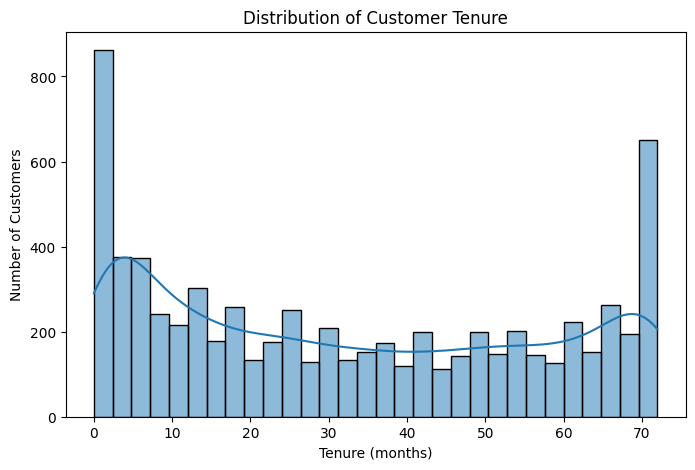

In [11]:
# Task 12 — numerical feature 1: distribution plot

plt.figure(figsize=(8, 5))
sns.histplot(df["tenure"], bins=30, kde=True)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (months)")
plt.ylabel("Number of Customers")

plt.show()


**Observation:** Tenure is concentrated among newer and moderately established customers, with fewer customers at very high tenure values. This indicates that the dataset contains many relatively recent customers as well as a smaller long-term customer group.

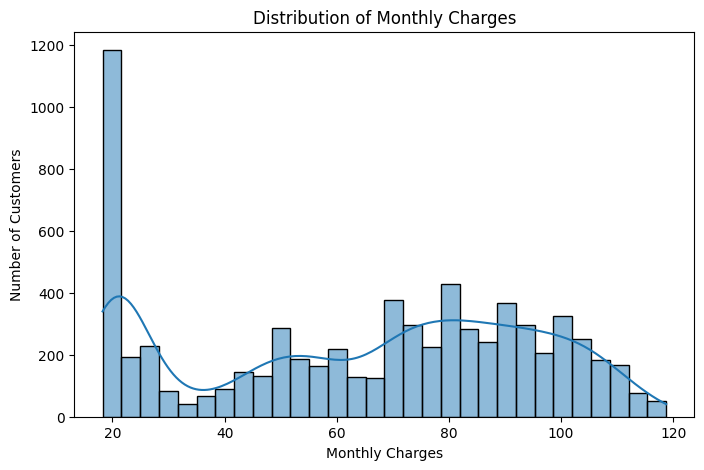

In [12]:
# Task 12 — numerical feature 2: distribution plot
plt.figure(figsize=(8, 5))
sns.histplot(df["MonthlyCharges"], bins=30, kde=True)
plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.show()

**Observation:** Monthly charges cover a wide range because customers subscribe to different service combinations. The distribution is not perfectly symmetric and contains higher-charge customers at the upper end.

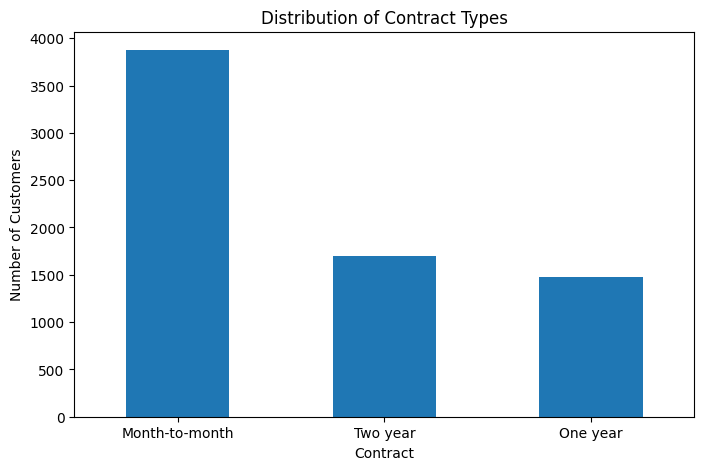

In [13]:
# Task 12 — categorical feature 1: distribution plot
df["Contract"].value_counts().plot(kind="bar", figsize=(8, 5))
plt.title("Distribution of Contract Types")
plt.xlabel("Contract")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

**Observation:**Month-to-month contracts form the largest customer group, while one-year and two-year contracts are less common. Contract type is therefore an important variable to investigate against churn.



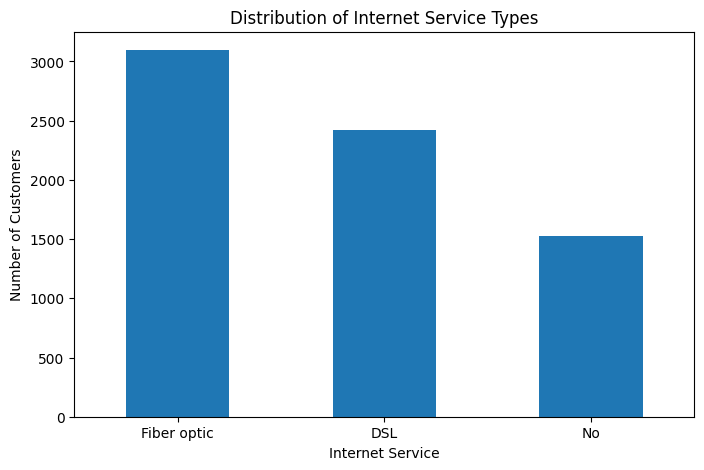

In [14]:
# Task 12 — categorical feature 2: distribution plot
df["InternetService"].value_counts().plot(kind="bar", figsize=(8, 5))
plt.title("Distribution of Internet Service Types")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

**Observation:** Customers are divided among DSL, fiber-optic, and no-internet-service groups. Because the group sizes differ, churn should be compared using rates rather than raw counts.

**Answer 13 (outliers / skew and possible explanation):**
`TotalCharges` is expected to be right-skewed because total spending accumulates as tenure increases. `MonthlyCharges` may contain legitimate high values because some customers use more or premium services. A statistical outlier is not automatically an error; it should be investigated before removal.

---

## Part 6 — Target Variable Analysis

The `Churn` column is what you will eventually predict. Before Lab 3, you need to understand its distribution — this has direct consequences for how a model should later be trained and evaluated.

*Concepts/functions you may find useful:* `df['Churn'].value_counts()`, `df['Churn'].value_counts(normalize=True)`

**Tasks**
14. Report the number and percentage of churned vs. non-churned customers. Is the target balanced or imbalanced?
15. In 2–3 sentences, explain why class imbalance might matter when a classification model is trained later — do not describe how to fix it, just why it matters.

In [15]:
# Task 14 — churn counts and percentages
churn_counts = df["Churn"].value_counts()
churn_pct = df["Churn"].value_counts(normalize=True).mul(100).round(2)

churn_report = pd.DataFrame({
    "Count": churn_counts,
    "Percentage": churn_pct
})
display(churn_report)

,Count,Percentage
Churn,,
No,5174,73.46
Yes,1869,26.54




```
# This is formatted as code
```

**Answer 14 (balanced or imbalanced?):**
The target is **imbalanced** because the non-churned class is much larger than the churned class. In the standard Telco Customer Churn dataset, about 26.5% churn and 73.5% do not churn.

**Answer 15 (why imbalance might matter later):**
A classifier can obtain high overall accuracy by favoring the majority class. That can hide poor performance on the minority churn class, even though correctly identifying churners is important for the business.


---

## Part 7 — Bivariate Analysis: Features vs. Churn

Now connect individual features to the target. You choose the appropriate visualization or summary for each feature type — a categorical feature is not explored the same way as a numerical one.

*Concepts/functions you may find useful:* `pd.crosstab(df[col], df['Churn'], normalize='index')`, `df.groupby(col)['Churn']...`, `sns.boxplot(x='Churn', y=col, data=df)`

**Tasks**
16. Investigate at least 2 categorical features (e.g. Contract, InternetService, PaymentMethod) against Churn. For each, record: Observation / Evidence / Possible Explanation.
17. Investigate at least 2 numerical features (e.g. tenure, MonthlyCharges) against Churn using the same Observation / Evidence / Possible Explanation format.

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


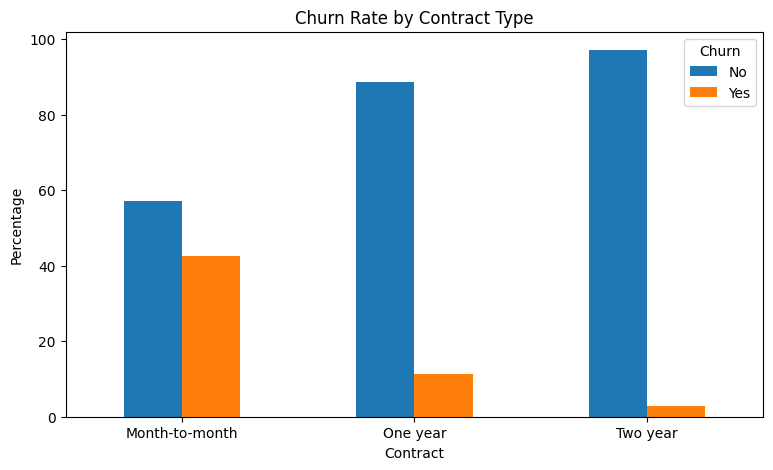

In [16]:
# Task 16 — categorical feature 1 vs Churn
contract_churn = pd.crosstab(
    df["Contract"], df["Churn"], normalize="index"
).mul(100).round(2)

display(contract_churn)

contract_churn.plot(kind="bar", figsize=(9, 5))
plt.title("Churn Rate by Contract Type")
plt.ylabel("Percentage")
plt.xlabel("Contract")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()


    Observation: Month-to-month customers have a much higher churn rate than one-year and two-year customers.

    Evidence: The row-normalized crosstab shows a substantially larger percentage of `Churn = Yes` for month-to-month customers.

    Possible Explanation: Short-term contracts have fewer commitment barriers, so customers may find it easier to leave.


Churn,No,Yes
InternetService,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


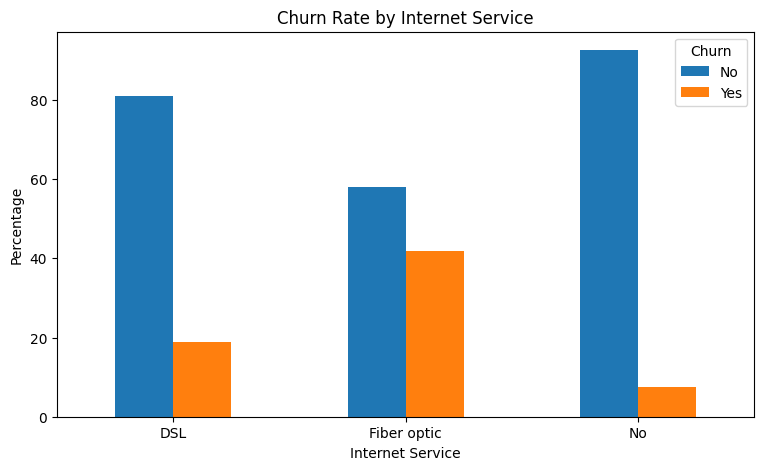

In [17]:
# Task 16 — categorical feature 2 vs Churn
internet_churn = pd.crosstab(
    df["InternetService"], df["Churn"], normalize="index"
).mul(100).round(2)

display(internet_churn)

internet_churn.plot(kind="bar", figsize=(9, 5))
plt.title("Churn Rate by Internet Service")
plt.ylabel("Percentage")
plt.xlabel("Internet Service")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

**Observation:** Churn rates differ across internet-service categories, with fiber-optic customers showing a notably higher churn rate than DSL and no-internet customers.
**Evidence:** The row-normalized crosstab reports a higher percentage of `Churn = Yes` for fiber-optic customers.
**Possible Explanation:** The difference may be associated with price, service expectations, competition, or service quality. EDA shows association, not causation.

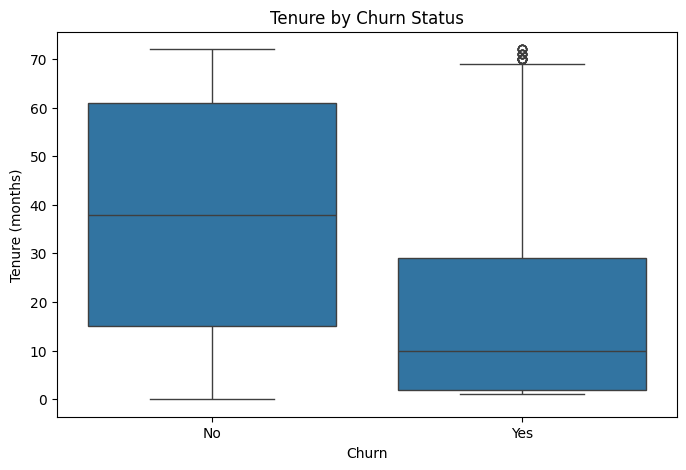

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


In [18]:
# Task 17 — numerical feature 1 vs Churn
plt.figure(figsize=(8, 5))
sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Tenure by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Tenure (months)")
plt.show()

display(df.groupby("Churn")["tenure"].describe())

**Observation:** Churned customers generally have lower tenure than customers who stay.
**Evidence:** The boxplot and group statistics show a lower central tendency for tenure among customers with `Churn = Yes`.
**Possible Explanation:** Newer customers may have less loyalty or may switch providers more easily.

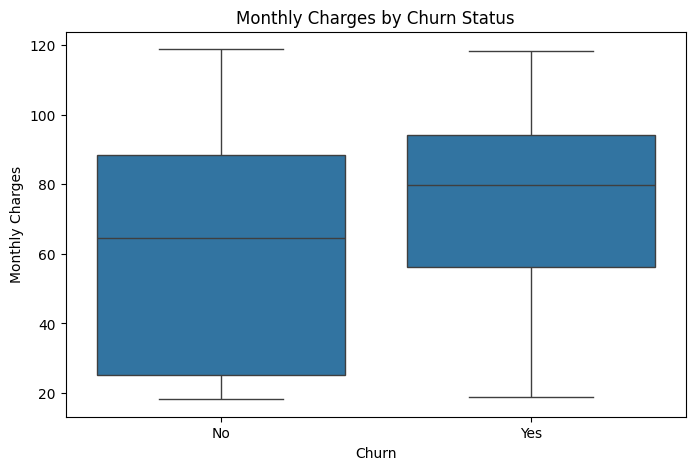

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


In [19]:
# Task 17 — numerical feature 2 vs Churn
plt.figure(figsize=(8, 5))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

display(df.groupby("Churn")["MonthlyCharges"].describe())

**Observation:** Churned customers tend to have higher monthly charges than customers who remain.
**Evidence:** The boxplot shows a higher distribution of `MonthlyCharges` for the churned group.
**Possible Explanation:** Higher bills may be associated with expensive service packages or price sensitivity. This is an association, not proof of a causal relationship.

---

## Part 8 — Correlation & Feature Relationships

Numerical features can be related to each other, not just to the target. Strongly correlated features can cause redundancy problems later, so it's worth knowing about them now.

*Concepts/functions you may find useful:* `df.corr(numeric_only=True)`, `sns.heatmap(corr_matrix, annot=True)`

**Tasks**
18. Compute and visualize the correlation matrix of the numerical features. Which pairs appear most correlated?
19. Does correlation imply causation here? Could any highly correlated features cause problems for a future model? Answer in 2–3 sentences.

,SeniorCitizen,tenure,MonthlyCharges
SeniorCitizen,1.000000,0.016567,0.220173
tenure,0.016567,1.000000,0.247900
MonthlyCharges,0.220173,0.247900,1.000000


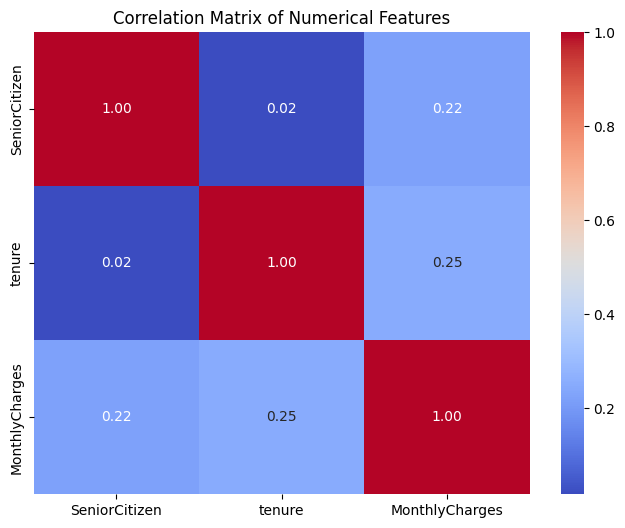

Strongest correlation pairs:


tenure          MonthlyCharges    0.247900
SeniorCitizen   MonthlyCharges    0.220173
                tenure            0.016567
                SeniorCitizen          NaN
tenure          SeniorCitizen          NaN
                tenure                 NaN
MonthlyCharges  SeniorCitizen          NaN
                tenure                 NaN
                MonthlyCharges         NaN
dtype: float64

In [20]:
# Task 18 — correlation matrix and heatmap
numeric_clean = df.select_dtypes(include=np.number)
corr_matrix = numeric_clean.corr()

display(corr_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")
plt.show()

corr_pairs = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
).stack().sort_values(key=abs, ascending=False)

print("Strongest correlation pairs:")
display(corr_pairs.head(10))


**Answer 18 (most correlated pairs):**
The strongest relationship is normally between **tenure and TotalCharges**, because accumulated charges increase as a customer stays longer. The exact correlation values and other strong pairs are printed by the code.

**Answer 19 (correlation vs. causation; potential problems):**
Correlation does not imply causation. Highly correlated predictors may contain overlapping information and can create redundancy or multicollinearity issues for some future models.


---

## Part 9 — Data Leakage Awareness

In Lab 3 you will train a classifier. Before that, you must check whether any column contains information that would not realistically be available at the moment of prediction — using such a column would make a model look artificially accurate.

**Tasks**
20. Inspect the columns for anything that looks like it could only be known after a customer has already churned, or that is purely an identifier. List any suspects and explain your reasoning.
21. In 2–3 sentences, explain what would go wrong if such a column were left in the model's input features.

**Answer 20 (suspect columns and reasoning):**
- **customerID** — a pure identifier, so it should not be used as a predictive feature.
- **Churn** — the target itself and must not be used as an input feature.
- There is no obvious post-churn outcome column in the standard dataset. Any column recorded only after cancellation would be a leakage risk and should be excluded.


**Answer 21 (what would go wrong):**
A leakage column gives the model information that would not be available when making a real prediction. This can make validation results look artificially strong while causing poor real-world performance.


---

## Part 10 — ML-Readiness Checklist

Summarize every column's fate in a single table. This is the bridge between EDA and modeling — Lab 3 will use this table directly.

**Task**
22. Complete the ML-readiness table for **every** column in the dataset.

| Column | Type | Role | Action | Reason |
|---|---|---|---|---|
| customerID | Identifier | Identifier | Remove | Unique ID; not a meaningful predictive feature. |
| gender | Categorical | Feature | Keep | Demographic feature. |
| SeniorCitizen | Numerical/binary | Feature | Keep | Customer status feature. |
| Partner | Categorical | Feature | Keep | Household/relationship information. |
| Dependents | Categorical | Feature | Keep | Household information. |
| tenure | Numerical | Feature | Keep | Length of customer relationship. |
| PhoneService | Categorical | Feature | Keep | Service information. |
| MultipleLines | Categorical | Feature | Keep | Service configuration. |
| InternetService | Categorical | Feature | Keep | Internet service type. |
| OnlineSecurity | Categorical | Feature | Keep | Add-on service. |
| OnlineBackup | Categorical | Feature | Keep | Add-on service. |
| DeviceProtection | Categorical | Feature | Keep | Add-on service. |
| TechSupport | Categorical | Feature | Keep | Add-on service. |
| StreamingTV | Categorical | Feature | Keep | Service usage/subscription. |
| StreamingMovies | Categorical | Feature | Keep | Service usage/subscription. |
| Contract | Categorical | Feature | Keep | Contract commitment. |
| PaperlessBilling | Categorical | Feature | Keep | Billing preference. |
| PaymentMethod | Categorical | Feature | Keep | Payment method. |
| MonthlyCharges | Numerical | Feature | Keep | Current monthly billing. |
| TotalCharges | Numerical | Feature | Keep | Accumulated billing after cleaning. |
| Churn | Categorical | Target | Keep as target only | Outcome to predict. |


_(Add one row per remaining column — copy the pattern above.)_

---

## Part 11 — Building the Clean Dataset

Bring together every cleaning decision into one final dataframe, `clean_df`, that Lab 3 can load directly.

> Do **not** split into train/test, encode categorical variables, or train any model — that happens in Lab 3.

**Tasks**
23. Produce `clean_df` with correct data types, missing values handled, duplicates handled, and irrelevant identifier columns removed where justified. Save it (e.g. `clean_churn.csv`) alongside your notebook.
24. Print `df.info()` (or equivalent) for `clean_df` as final proof that every issue identified earlier has been resolved.

In [21]:
# Task 23 — assemble clean_df from your cleaning decisions
clean_df = df.copy()

for col in clean_df.select_dtypes(include="object").columns:
    clean_df[col] = clean_df[col].str.strip()

clean_df["TotalCharges"] = pd.to_numeric(clean_df["TotalCharges"], errors="coerce")

clean_df.loc[
    clean_df["TotalCharges"].isna() & (clean_df["tenure"] == 0),
    "TotalCharges"
] = 0

clean_df = clean_df.drop_duplicates()
clean_df = clean_df.drop_duplicates(subset="customerID")
clean_df = clean_df.drop(columns=["customerID"])

clean_df.to_csv("clean_churn.csv", index=False)

print("Saved: clean_churn.csv")
print("Final shape:", clean_df.shape)


C:\Users\wajood ali\AppData\Local\Temp\ipykernel_13712\107957974.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in clean_df.select_dtypes(include="object").columns:


Saved: clean_churn.csv
Final shape: (7043, 20)


In [22]:
# Task 24 — final proof: info() / isnull().sum() / duplicated().sum() on clean_df
print("Final clean_df information:")
clean_df.info()

print("\nMissing values:")
display(clean_df.isnull().sum())

print("\nDuplicate rows:", clean_df.duplicated().sum())
print("\nTotalCharges dtype:", clean_df["TotalCharges"].dtype)
print("\nFirst five rows:")
display(clean_df.head())

Final clean_df information:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 no

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


Duplicate rows: 22

TotalCharges dtype: float64

First five rows:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


---

## Part 12 — Key Findings & Final Reflection

Step back from the code and summarize what you actually learned about this dataset and this problem.

**Task 25 — Five Important Findings**

Repeat this block for each of your five findings.

**Finding 1**
- Observation: Contract type is strongly associated with churn.
- Evidence: Month-to-month customers have a much higher churn rate than longer-contract customers.
- Interpretation: Contract commitment appears to be an important retention-related feature.

**Finding 2**
- Observation: Churned customers generally have shorter tenure.
- Evidence: The tenure boxplot and group statistics show lower tenure for the churned group.
- Interpretation: Newer customers appear more likely to leave.

**Finding 3**
- Observation: Churned customers tend to have higher monthly charges.
- Evidence: The MonthlyCharges boxplot shows a higher distribution for churned customers.
- Interpretation: Billing level and service package may be related to churn.


**Finding 4**
- Observation: Tenure and TotalCharges are strongly positively correlated.
- Evidence: The numerical correlation matrix shows a high positive correlation between them.
- Interpretation: This is expected because total spending accumulates with customer tenure.


**Finding 5**
- Observation: The Churn target is imbalanced.
- Evidence: The non-churned class is much larger than the churned class.
- Interpretation: Future model evaluation should pay attention to the minority churn class rather than relying only on accuracy.


---

**Task 26 — Final Reflection Questions**

1. What was the most important data-quality issue you found?
  `TotalCharges` was stored as text and contained blank values even though it represents a numerical amount. It needed numeric conversion and missing-value handling.
2. What was the most interesting pattern you discovered?
   Month-to-month customers have a much higher churn rate than customers on longer contracts.
3. Which feature seems most useful for predicting churn?
  `Contract` appears particularly useful because churn rates differ substantially across contract types. `tenure` and `MonthlyCharges` are also useful.
4. Which feature should probably not be used, and why?
  `customerID` should not be used because it is only an identifier and does not represent customer behavior.
5. What preprocessing will be required before ML modeling (conceptually — do not implement it)?
   Categorical variables will need encoding, numerical variables may need scaling depending on the model, and the target must be separated from the input features. The class imbalance should also be considered during model evaluation.
6. What would you do next if you had another 3 hours?
   I would perform deeper customer-segment analysis, inspect more feature relationships, investigate interactions, and prepare the cleaned feature set for the classification task in Lab 3.


---

## Bonus Tasks (Optional)

- Create one additional meaningful visualization not required above.
- Investigate a surprising customer subgroup you didn't expect to find.
- Calculate churn rate across a combination of 2+ customer segments at once.
- Identify one possible feature-engineering opportunity for Lab 3.
- Identify one possible source of bias in this dataset.

In [23]:
# Bonus — optional exploration
bonus = pd.crosstab(
    [clean_df["Contract"], clean_df["InternetService"]],
    clean_df["Churn"],
    normalize="index"
).mul(100).round(2)

display(bonus)

print("Potential feature-engineering idea: service_count")
print("A future Lab 3 feature could count the number of subscribed service/add-on features.")

Churn                              No    Yes
Contract       InternetService              
Month-to-month DSL              67.78  32.22
               Fiber optic      45.39  54.61
               No               81.11  18.89
One year       DSL              90.70   9.30
               Fiber optic      80.71  19.29
               No               97.53   2.47
Two year       DSL              98.09   1.91
               Fiber optic      92.77   7.23
               No               99.22   0.78

Potential feature-engineering idea: service_count
A future Lab 3 feature could count the number of subscribed service/add-on features.


---

## Submission Checklist

Before submitting, confirm you have:

- [ ] Completed all 26 tasks above, with written interpretation for every chart and decision
- [ ] A working `clean_df`, saved as `clean_churn.csv`
- [ ] A completed ML-readiness table (Part 10) covering every column
- [ ] Five Key Findings written (Part 12)
- [ ] Answered all six Final Reflection questions
- [ ] Committed and pushed this notebook + `clean_churn.csv` to your GitHub repository
- [ ] Added your GitHub repository link at the top of this notebook